# Acero

In [1]:
import pandas as pd 
import numpy as np 
import scipy as sp 
import matplotlib.pyplot as plt 

In [2]:
def get_last_second_amplitude(t, V):
    t = np.asarray(t)
    V = np.asarray(V)
        
    t_end = t[-1]
    t_start = t_end - 1.0
    
    mask = t >= t_start
    
    V_last_second = V[mask]
    
    if len(V_last_second) == 0:
        return 0.0
        
    amplitude = (np.max(V_last_second) - np.min(V_last_second)) / 2.0
    
    return amplitude

In [3]:
import glob

amplitudes = []
frequencies = []

# Loop through all csv files in the folder
for file_path in glob.glob('data_clean_cuarta_clase/acero/*.csv'):
    
    # 1. Extract the frequency from the first line like before
    with open(file_path, 'r', encoding='utf-8') as file:
        first_line = file.readline()
        freq = float(first_line.split('frecuencia:')[1].strip())
        frequencies.append(freq)
        
    # 2. Read the actual data using pandas
    # skiprows=2 ignores the first two metadata lines so it uses "Time (s),Voltage (V)" as headers
    df = pd.read_csv(file_path, skiprows=2)
    
    # Extract the columns into variables t and V
    t = df['Time (s)'].values
    V = df['Voltage (V)'].values
    
    # 3. Apply your function
    amp = get_last_second_amplitude(t, V)
    
    # 4. Save the amplitude to our array
    amplitudes.append(amp)

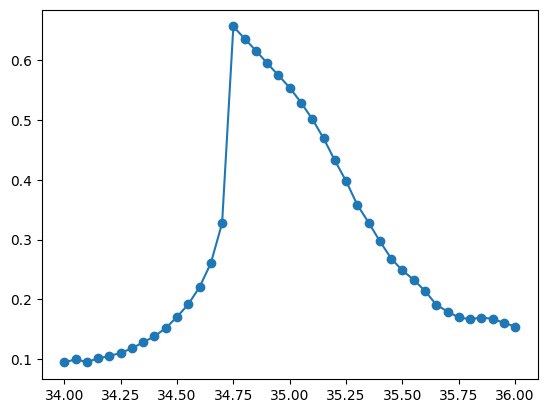

In [4]:
plt.plot(frequencies, amplitudes, marker='o') 

In [5]:
f_data = np.array(frequencies)
a_data = np.array(amplitudes)

<>:112: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:112: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\nysg\AppData\Local\Temp\ipykernel_9236\2225602212.py:112: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  plt.xlabel('Driving Frequency $\omega$')


w0 = 35.174, alpha = -120.62, zeta = 2.50e-05, F = 7.660


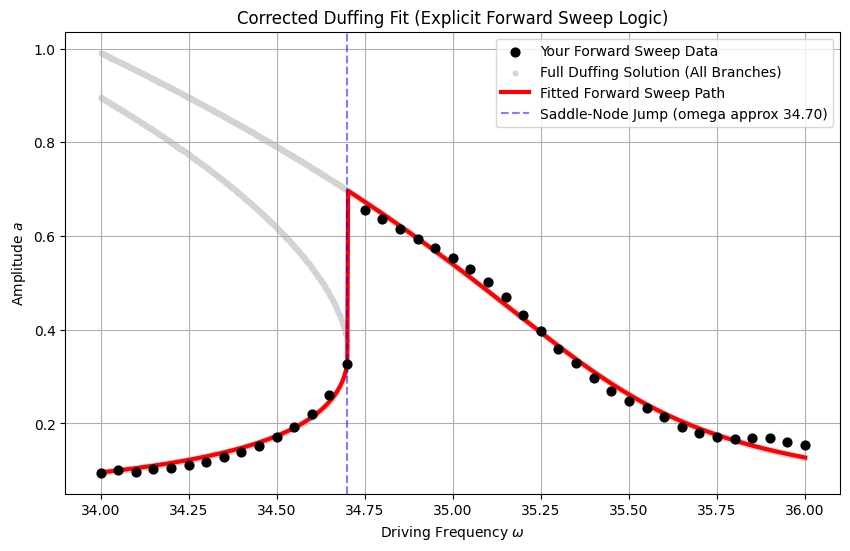

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Your provided data
w_data = np.array([34., 34.05, 34.1, 34.15, 34.2, 34.25, 34.3, 34.35, 34.4, 34.45, 
                   34.5, 34.55, 34.6, 34.65, 34.7, 34.75, 34.8, 34.85, 34.9, 34.95, 
                   35., 35.05, 35.1, 35.15, 35.2, 35.25, 35.3, 35.35, 35.4, 35.45, 
                   35.5, 35.55, 35.6, 35.65, 35.7, 35.75, 35.8, 35.85, 35.9, 35.95, 36.])

a_data = np.array([0.0947, 0.1001, 0.0956, 0.1016, 0.1055, 0.1107, 0.1183, 0.1285, 0.1384, 0.1521, 
                   0.1709, 0.1918, 0.2207, 0.2605, 0.3273, 0.6559, 0.6356, 0.6155, 0.5946, 0.5742, 
                   0.5536, 0.5289, 0.5013, 0.4693, 0.4322, 0.3977, 0.3578, 0.3284, 0.2972, 0.2684, 
                   0.2484, 0.2330, 0.2142, 0.1913, 0.1798, 0.1699, 0.1670, 0.1697, 0.1678, 0.1609, 0.1547])

def simulate_forward_sweep(w_array, w0, alpha, zeta, F):
    """
    Solves the exact Duffing cubic at each step, dropping unstable roots 
    and enforcing the continuity of a physical forward sweep.
    """
    a_sim = np.zeros(len(w_array))
    current_a = 0.0
    
    for i, w in enumerate(w_array):
        # Coefficients for the cubic in terms of x = a^2
        C3 = (9/16) * alpha**2
        C2 = (3/2) * alpha * (w0**2 - w**2)
        C1 = (w0**2 - w**2)**2 + 4 * zeta**2 * w0**2 * w**2
        C0 = -F**2
        
        # Find roots of the cubic
        roots = np.roots([C3, C2, C1, C0])
        
        # Filter for real, positive roots (amplitude must be real/positive)
        real_roots = np.real(roots[np.isclose(np.imag(roots), 0, atol=1e-8)])
        pos_roots = np.sort(real_roots[real_roots > 0])
        
        if len(pos_roots) == 0:
            a_sim[i] = current_a
            continue
            
        pos_a = np.sqrt(pos_roots)
        
        # Continuity logic for a Forward Sweep
        if i == 0:
            current_a = pos_a[0] # Start on the lowest stable branch
        else:
            if len(pos_a) == 1:
                current_a = pos_a[0]
            elif len(pos_a) == 3:
                a_low, a_mid, a_high = pos_a
                # a_mid is mathematically unstable. 
                # Pick lower or upper based on where we are.
                if current_a < a_mid:
                    current_a = a_low
                else:
                    current_a = a_high
            else:
                # Exactly at bifurcation boundary
                idx = np.argmin(np.abs(pos_a - current_a))
                current_a = pos_a[idx]
                
        a_sim[i] = current_a
        
    return a_sim

# Cost function for the optimizer
def cost_fn(params):
    w0, alpha, zeta, F = params
    if zeta < 0 or F < 0: # Physical bounds
        return 1e6
    a_sim = simulate_forward_sweep(w_data, w0, alpha, zeta, F)
    return np.sum((a_sim - a_data)**2)

# Initial guess (from an earlier implicit fit)
p0 = [35.18, -96.6, 0.01, 7.9]

# Nelder-Mead avoids gradient issues around the discontinuous jump
res = minimize(cost_fn, p0, method='Nelder-Mead')
w0_opt, alpha_opt, zeta_opt, F_opt = res.x

print(f"w0 = {w0_opt:.3f}, alpha = {alpha_opt:.2f}, zeta = {zeta_opt:.2e}, F = {F_opt:.3f}")

# ----- PLOTTING -----
w_high_res = np.linspace(34.0, 36.0, 1000)
a_high_res = simulate_forward_sweep(w_high_res, w0_opt, alpha_opt, zeta_opt, F_opt)

# Calculate ALL mathematical roots just for the background visual
w_roots, a_roots = [], []
for w in w_high_res:
    C3 = (9/16)*alpha_opt**2
    C2 = (3/2)*alpha_opt*(w0_opt**2 - w**2)
    C1 = (w0_opt**2 - w**2)**2 + 4*zeta_opt**2 * w0_opt**2 * w**2
    C0 = -F_opt**2
    roots = np.roots([C3, C2, C1, C0])
    r_real = np.real(roots[np.isclose(np.imag(roots), 0, atol=1e-8)])
    for r in np.sort(r_real[r_real > 0]):
        w_roots.append(w)
        a_roots.append(np.sqrt(r))

plt.figure(figsize=(10, 6))
plt.scatter(w_data, a_data, color='black', s=40, label='Your Forward Sweep Data', zorder=3)
plt.scatter(w_roots, a_roots, color='#d3d3d3', s=10, label='Full Duffing Solution (All Branches)', zorder=1)
plt.plot(w_high_res, a_high_res, 'r-', lw=3, label='Fitted Forward Sweep Path', zorder=2)

# Identify and plot the jump line
jump_indices = np.where(np.diff(a_high_res) > 0.1)[0]
if len(jump_indices) > 0:
    w_jump = w_high_res[jump_indices[0]]
    plt.axvline(w_jump, color='blue', linestyle='--', alpha=0.5, label=f'Saddle-Node Jump (omega approx {w_jump:.2f})')

plt.xlabel('Driving Frequency $\omega$')
plt.ylabel('Amplitude $a$')
plt.title('Corrected Duffing Fit (Explicit Forward Sweep Logic)')
plt.legend()
plt.grid(True)
plt.show()

# Time to settle vs freq

## Hilbert transform (failed)

In [7]:
data = np.loadtxt('data_clean_cuarta_clase/acero/measurement_20260625_131512.csv', delimiter=',',skiprows=3)
data2 = np.loadtxt('data_clean_cuarta_clase/acero/measurement_20260625_130601.csv', delimiter=',',skiprows=3)

(0.0, 2.0)

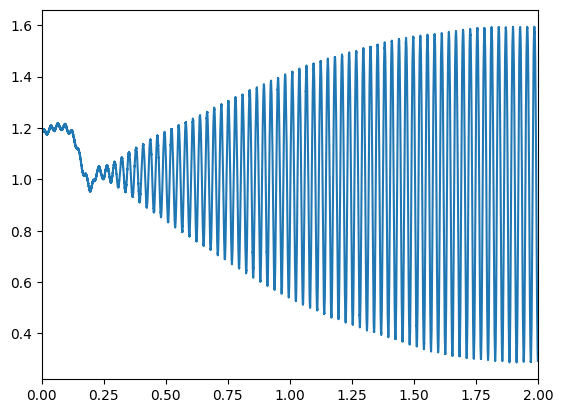

In [8]:
plt.plot(data[:,0], data[:,1])
plt.xlim(0,2)

In [10]:
import glob
import numpy as np
import pandas as pd
from scipy.signal import hilbert
from scipy.optimize import curve_fit

def get_time_constant(t, y):
    """
    Extracts the time constant (tau) from a transient signal 
    using the Hilbert transform and an exponential fit.
    """
    # 1. Trim the first 0.5s of data
    trim_mask = t >= 0.5
    t_clean = t[trim_mask]
    y_clean = y[trim_mask]
    
    # 2. Remove DC Offset
    y_centered = y_clean - np.mean(y_clean)
    
    # 3. Extract envelope
    analytic_signal = hilbert(y_centered)
    envelope = np.abs(analytic_signal)
    
    # 4. Isolate decay safely (ignore 5% edges to avoid Hilbert artifacts)
    margin = int(len(envelope) * 0.05)
    
    # Ensure there is enough data to apply the margin
    if len(envelope) <= 2 * margin:
        return np.nan 
        
    peak_idx = np.argmax(envelope[margin:-margin]) + margin
    t_decay = t_clean[peak_idx:]
    envelope_decay = envelope[peak_idx:]
    
    # 5. Define decay function locally
    def exp_decay(t_data, A, tau, C):
        t0 = t_decay[0] 
        return A * np.exp(-(t_data - t0) / tau) + C
    
    # 6. Fit the curve
    initial_guess = [np.max(envelope_decay) - np.min(envelope_decay), 1.0, np.min(envelope_decay)]
    
    try:
        # maxfev increases the allowed iterations to help tough fits converge
        popt, pcov = curve_fit(exp_decay, t_decay, envelope_decay, p0=initial_guess, maxfev=2000)
        tau_fit = popt[1] # The second parameter is tau
        return tau_fit
    except RuntimeError:
        # If the curve_fit fails to converge, return NaN instead of crashing the loop
        return np.nan


# --- Main Loop Execution ---

taus = []
frequencies = []

# Loop through all csv files in the folder
for file_path in glob.glob('data_clean_cuarta_clase/acero/*.csv'):
    
    # 1. Extract the frequency from the first line
    with open(file_path, 'r', encoding='utf-8') as file:
        first_line = file.readline()
        freq = float(first_line.split('frecuencia:')[1].strip())
        frequencies.append(freq)
        
    # 2. Read the actual data using pandas
    df = pd.read_csv(file_path, skiprows=2)
    
    # Extract the columns into variables t and V
    t = df['Time (s)'].values
    V = df['Voltage (V)'].values
    
    # 3. Apply the new time constant function
    tau = get_time_constant(t, V)
    
    # 4. Save tau to our array
    taus.append(tau)
    
    # Optional: Print progress so you know it's working
    print(f"Processed file: {file_path} | Freq: {freq} Hz | Tau: {tau:.4f}")

# At the end, you can easily load this into a new DataFrame for analysis
results_df = pd.DataFrame({
    'Frequency (Hz)': frequencies,
    'Tau (s)': taus
})

Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130601.csv | Freq: 34.0 Hz | Tau: 0.1154
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130647.csv | Freq: 34.05 Hz | Tau: 0.0790
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130726.csv | Freq: 34.1 Hz | Tau: 3.1724
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130759.csv | Freq: 34.15 Hz | Tau: 0.1006
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130831.csv | Freq: 34.2 Hz | Tau: 0.6071
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130859.csv | Freq: 34.25 Hz | Tau: 0.0944
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130922.csv | Freq: 34.3 Hz | Tau: 0.1043
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130947.csv | Freq: 34.35 Hz | Tau: 0.1783


C:\Users\nysg\AppData\Local\Temp\ipykernel_19048\2916163089.py:38: RuntimeWarning: overflow encountered in exp
  return A * np.exp(-(t_data - t0) / tau) + C


Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131012.csv | Freq: 34.4 Hz | Tau: 0.1528
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131036.csv | Freq: 34.45 Hz | Tau: 0.1568
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131057.csv | Freq: 34.5 Hz | Tau: 0.1461
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131121.csv | Freq: 34.55 Hz | Tau: 0.2039
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131146.csv | Freq: 34.6 Hz | Tau: 0.2590
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131210.csv | Freq: 34.65 Hz | Tau: 0.3439
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131233.csv | Freq: 34.7 Hz | Tau: 0.6418
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131307.csv | Freq: 34.75 Hz | Tau: 0.6887
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131336.csv | Freq: 34.8 Hz | Tau: 0.5744
Processed file: data_cle

(0.0, 0.8)

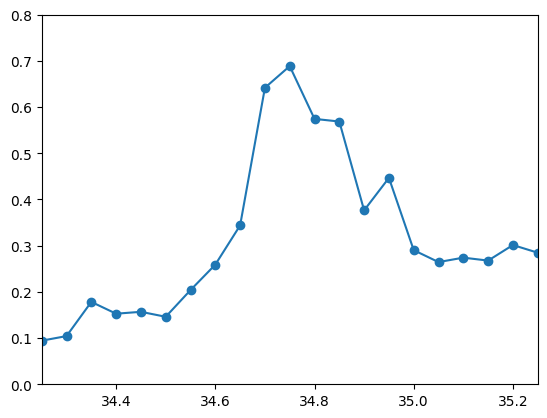

In [11]:
plt.plot(frequencies, taus, marker='o', label='Amplitude')
plt.xlim(34.25,35.25)
plt.ylim(0,0.8)


## Lock-in

In [6]:
from scipy.signal import butter, filtfilt, find_peaks
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

string = "data_clean_cuarta_clase/acero/measurement_20260625_130859.csv"

data = np.loadtxt(string, delimiter=',',skiprows=3)
freq = float(open(string, 'r').readline().split('frecuencia:')[1].strip())

print(f"Frequency extracted from file: {freq} Hz")

Frequency extracted from file: 34.25 Hz


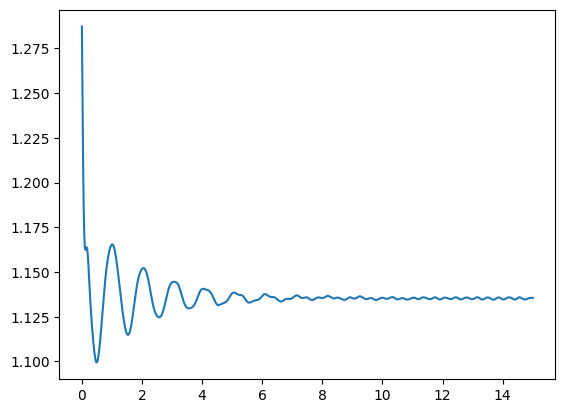

In [7]:

# 1. Extract your data arrays
t_raw = data[:, 0]
y_raw = data[:, 1]

# Center temporarily to find the true signal power
y_temp = y_raw - np.mean(y_raw)

# Find all peaks of the absolute signal 
# 'distance' ensures we don't accidentally pick two points on the same carrier cycle
sampling_rate = 1 / (t_raw[1] - t_raw[0])
peaks, _ = find_peaks(np.abs(y_temp), distance=int(sampling_rate / 34))

# Find the first peak that is part of the actual signal, not background noise
# We look for the first peak that exceeds 30% of the absolute maximum value in the dataset
threshold = 0.3 * np.max(np.abs(y_temp))
valid_peaks = peaks[np.abs(y_temp)[peaks] > threshold]

# Your true start index is the very first prominent peak
start_idx = valid_peaks[0]

# Chop both arrays to start exactly at this maximum
t = t_raw[start_idx:]
y_chopped = y_raw[start_idx:]
# ==========================================

# 2. Define your carrier parameters
f_c = freq 
omega_c = 2 * np.pi * f_c

# 3. Preprocessing: Remove DC offset using the CLEAN, chopped data
dc_offset = np.mean(y_chopped)
y_centered = y_chopped - dc_offset

# 4. Lock-in Step (Using chopped arrays)
I_mixed = y_centered * np.cos(omega_c * t)  
Q_mixed = y_centered * np.sin(omega_c * t)  

# 5. Low-Pass Filter Design
nyquist = 0.5 * sampling_rate
cutoff_freq = 5.0  
b, a = butter(N=4, Wn=cutoff_freq / nyquist, btype='low')

# 6. Filter
I_filtered = filtfilt(b, a, I_mixed)
Q_filtered = filtfilt(b, a, Q_mixed)

# 7. Reconstruct Magnitude
envelope = 2 * np.sqrt(I_filtered**2 + Q_filtered**2)

# 8. Postprocessing: Add the DC offset back
envelope_final = envelope + dc_offset

# 't' and 'envelope_final' are now perfectly aligned, starting at the first peak!
plt.plot(t, envelope_final)
# plt.xlim(0,10)

--- Fit Results ---
Decay time constant (tau): 1.6786 seconds
Initial amplitude (A):     0.0541
Asymptotic offset (y0):    1.1359
Half-life (t_1/2):         1.1635 seconds


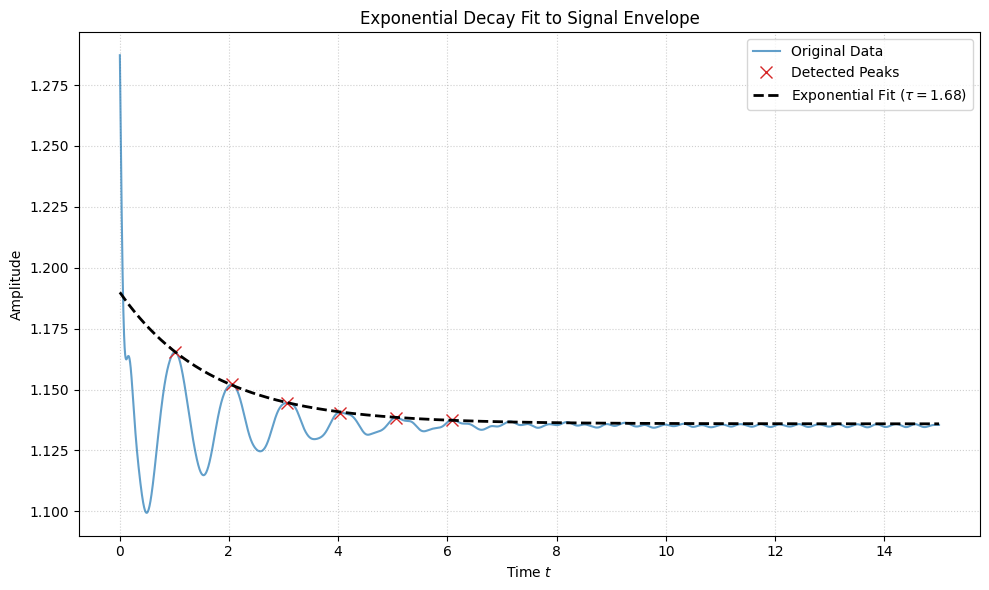

In [8]:
peaks, _ = find_peaks(envelope_final, prominence=0.003)

t_peaks = t[peaks]
y_peaks = envelope_final[peaks]

# 2. Define the Exponential Decay Function
def exp_decay(t, A, tau, y0):
    return A * np.exp(-t / tau) + y0

# 3. Establish Initial Guesses (p0)
# Providing good initial guesses prevents the curve_fit algorithm from failing to converge.
y0_guess = np.mean(envelope_final[-100:]) # Average of the steady-state tail
A_guess = y_peaks[0] - y0_guess           # First peak height relative to the offset
tau_guess = 2.0                           # Rough visual estimate of the decay time

p0 = [A_guess, tau_guess, y0_guess]

# 4. Perform the Non-Linear Curve Fit
popt, pcov = curve_fit(exp_decay, t_peaks, y_peaks, p0=p0)
A_fit, tau_fit, y0_fit = popt

# 5. Output the Relevant Parameters
print("--- Fit Results ---")
print(f"Decay time constant (tau): {tau_fit:.4f} seconds")
print(f"Initial amplitude (A):     {A_fit:.4f}")
print(f"Asymptotic offset (y0):    {y0_fit:.4f}")

# Optional: Calculate the Half-Life (time to decay by 50%)
half_life = tau_fit * np.log(2)
print(f"Half-life (t_1/2):         {half_life:.4f} seconds")

# 6. Generate the Plot
plt.figure(figsize=(10, 6))

# Plot original data
plt.plot(t, envelope_final, label='Original Data', color='tab:blue', alpha=0.7)

# Highlight the peaks used for fitting
plt.plot(t_peaks, y_peaks, 'x', color='tab:red', markersize=8, label='Detected Peaks')

# Plot the fitted exponential curve
t_fit = np.linspace(t[0], t[-1], 1000)
plt.plot(t_fit, exp_decay(t_fit, *popt), '--', color='black', linewidth=2,
         label=rf'Exponential Fit ($\tau = {tau_fit:.2f}$)')

# Formatting
plt.xlabel('Time $t$')
plt.ylabel('Amplitude')
plt.title('Exponential Decay Fit to Signal Envelope')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

Frequency extracted: 34.0 Hz

--- Fit Results ---
Decay time const (tau): 1.5481 s
Initial amplitude (A):  -0.0861
Asymptotic offset (y0): 1.1288
Half-life (t_1/2):      1.0731 s


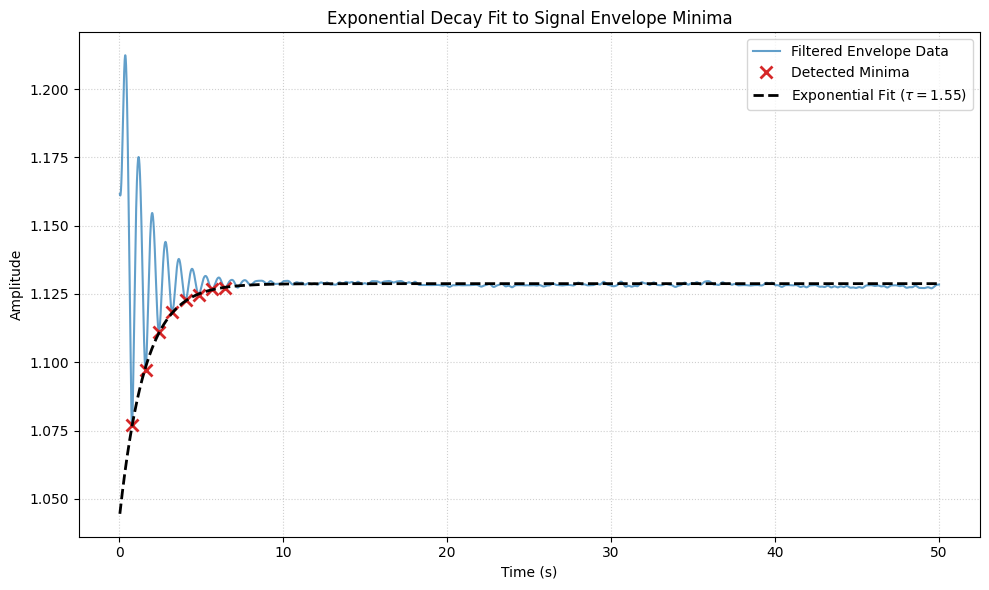

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, savgol_filter
from scipy.optimize import curve_fit

def load_and_chop_data(filepath, peak_threshold_ratio=0.3):
    """
    Loads data, extracts frequency, and chops the signal starting from the first valid peak.
    """
    # Load data and frequency
    data = np.loadtxt(filepath, delimiter=',', skiprows=3)
    with open(filepath, 'r') as f:
        freq = float(f.readline().split('frecuencia:')[1].strip())
        
    t_raw = data[:, 0]
    y_raw = data[:, 1]
    sampling_rate = 1 / (t_raw[1] - t_raw[0])
    
    # Center temporarily to find the true signal power
    y_temp = y_raw - np.mean(y_raw)
    
    # Find peaks and chop
    peaks, _ = find_peaks(np.abs(y_temp), distance=int(sampling_rate / 34))
    threshold = peak_threshold_ratio * np.max(np.abs(y_temp))
    valid_peaks = peaks[np.abs(y_temp)[peaks] > threshold]
    start_idx = valid_peaks[0]
    
    t_chopped = t_raw[start_idx:]
    y_chopped = y_raw[start_idx:]
    
    return t_chopped, y_chopped, freq, sampling_rate

def process_lock_in(t, y, f_c, sampling_rate, cutoff_freq=2.0, smooth_window_ms=50):
    """
    Performs lock-in amplification (mixing, low-pass filtering) and envelope smoothing.
    """
    omega_c = 2 * np.pi * f_c
    
    # Remove DC offset
    dc_offset = np.mean(y)
    y_centered = y - dc_offset
    
    # Mixing
    I_mixed = y_centered * np.cos(omega_c * t)  
    Q_mixed = y_centered * np.sin(omega_c * t)  
    
    # Filtering
    nyquist = 0.5 * sampling_rate
    b, a = butter(N=4, Wn=cutoff_freq / nyquist, btype='low')
    I_filtered = filtfilt(b, a, I_mixed)
    Q_filtered = filtfilt(b, a, Q_mixed)
    
    # Reconstruct Magnitude
    envelope = 2 * np.sqrt(I_filtered**2 + Q_filtered**2)
    
    # Savitzky-Golay Smoothing
    window_length = int(sampling_rate * (smooth_window_ms / 1000.0))
    if window_length % 2 == 0: 
        window_length += 1
    
    # Ensure window length isn't larger than the data array
    if window_length > len(envelope):
        window_length = len(envelope) - 1 if (len(envelope) - 1) % 2 != 0 else len(envelope) - 2
        
    envelope_smoothed = savgol_filter(envelope, window_length, polyorder=3)
    
    # Add DC back
    return envelope_smoothed + dc_offset

def exp_decay(t, A, tau, y0):
    """Mathematical definition of exponential decay."""
    return A * np.exp(-t / tau) + y0

def fit_decay_to_minima(t, envelope, prominence=0.003):
    """
    Finds minima in the envelope and fits an exponential decay curve to them.
    """
    # Minima detection
    minima, _ = find_peaks(-envelope, prominence=prominence)
    t_minima = t[minima]
    y_minima = envelope[minima]
    
    # Initial Guesses
    y0_guess = np.mean(envelope[-100:]) 
    A_guess = y_minima[0] - y0_guess         
    tau_guess = 2.0                           
    p0 = [A_guess, tau_guess, y0_guess]
    
    # Curve fitting
    popt, _ = curve_fit(exp_decay, t_minima, y_minima, p0=p0)
    
    return popt, t_minima, y_minima

def plot_lockin_results(t, envelope, t_minima, y_minima, popt):
    """
    Generates and displays the final plot.
    """
    plt.figure(figsize=(10, 6))
    
    plt.plot(t, envelope, label='Filtered Envelope Data', color='tab:blue', alpha=0.7)
    plt.plot(t_minima, y_minima, 'x', color='tab:red', markersize=8, label='Detected Minima', markeredgewidth=2)
    
    t_fit = np.linspace(t[0], t[-1], 1000)
    plt.plot(t_fit, exp_decay(t_fit, *popt), '--', color='black', linewidth=2,
             label=rf'Exponential Fit ($\tau = {popt[1]:.2f}$)')
    
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('Exponential Decay Fit to Signal Envelope Minima')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# ==========================================
# Main Execution Block
# ==========================================

filepath = "data_clean_cuarta_clase\\acero\\measurement_20260625_130601.csv"

# 1. Load Data
t, y, f_c, fs = load_and_chop_data(filepath)
print(f"Frequency extracted: {f_c} Hz")

# 2. Lock-in Amplification
envelope = process_lock_in(t, y, f_c, fs, cutoff_freq=2.0, smooth_window_ms=50)

# 3. Minima Detection and Fitting
popt, t_minima, y_minima = fit_decay_to_minima(t, envelope, prominence=0.003)

A_fit, tau_fit, y0_fit = popt
half_life = tau_fit * np.log(2)

print("\n--- Fit Results ---")
print(f"Decay time const (tau): {tau_fit:.4f} s")
print(f"Initial amplitude (A):  {A_fit:.4f}")
print(f"Asymptotic offset (y0): {y0_fit:.4f}")
print(f"Half-life (t_1/2):      {half_life:.4f} s")

# 4. Plot
plot_lockin_results(t, envelope, t_minima, y_minima, popt)

(0.0, 10.0)

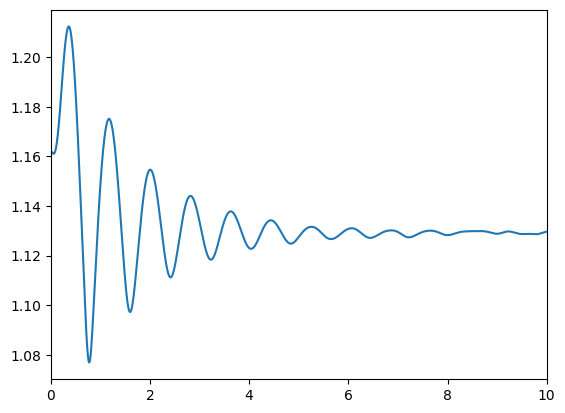

In [31]:
plt.plot(t,envelope)
plt.xlim(0,10)

In [32]:

"""
Loads data, extracts frequency, and chops the signal starting from the first valid peak.
"""
peak_threshold_ratio = 0.3  # Adjust this threshold as needed
filepath = "data_clean_cuarta_clase\\acero\\measurement_20260625_130601.csv"

# Load data and frequency
data = np.loadtxt(filepath, delimiter=',', skiprows=3)
with open(filepath, 'r') as f:
    freq = float(f.readline().split('frecuencia:')[1].strip())
    
t_raw = data[:, 0]
y_raw = data[:, 1]
sampling_rate = 1 / (t_raw[1] - t_raw[0])

# Center temporarily to find the true signal power
y_temp = y_raw - np.mean(y_raw)

# Find peaks and chop
peaks, _ = find_peaks(np.abs(y_temp), distance=int(sampling_rate / 34))
threshold = peak_threshold_ratio * np.max(np.abs(y_temp))
valid_peaks = peaks[np.abs(y_temp)[peaks] > threshold]
start_idx = valid_peaks[0]

t_chopped = t_raw[start_idx:]
y_chopped = y_raw[start_idx:]

t_chopped, y_chopped, freq, sampling_rate

(array([3.476000e-02, 3.480000e-02, 3.484000e-02, ..., 4.999988e+01,
        4.999992e+01, 4.999996e+01], shape=(1249131,)),
 array([1.10326388, 1.1030994 , 1.10227699, ..., 1.12382404, 1.12415301,
        1.12349508], shape=(1249131,)),
 34.0,
 np.float64(24999.999999999996))

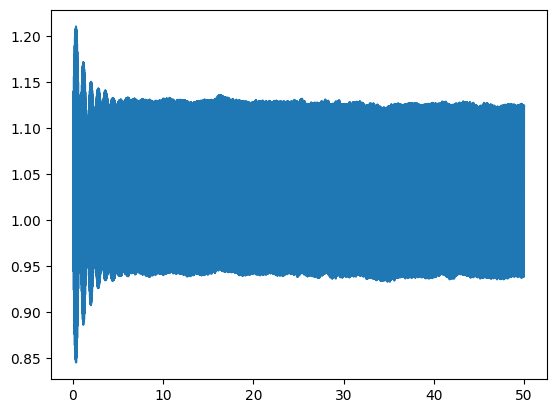

In [33]:
plt.plot(t_chopped, y_chopped)

### Loop

In [24]:
import glob
import os

# ==========================================
# Main Execution Block (Batch Processing with Logging)
# ==========================================

folder_path = "data_clean_cuarta_clase/acero/*.csv"

taus = []
frequencies = []
processed_files = []

print(f"Searching for files in: {folder_path}\n")
print(f"{'File Name':<35} | {'Freq (Hz)':<10} | {'Tau (s)':<10} | Status")
print("-" * 75)

for filepath in glob.glob(folder_path):
    filename = os.path.basename(filepath)
    
    try:
        # 1. Load Data
        t, y, f_c, fs = load_and_chop_data(filepath)
        
        # 2. Lock-in Amplification
        envelope = process_lock_in(t, y, f_c, fs, cutoff_freq=2.0, smooth_window_ms=30)

        # 3. Minima Detection and Fitting
        popt, t_minima, y_minima = fit_decay_to_minima(t, envelope, prominence=0.007)
        A_fit, tau_fit, y0_fit = popt
        
        # Save results
        taus.append(tau_fit)
        frequencies.append(f_c)
        processed_files.append(filename)
        
        # Success output for this iteration
        print(f"{filename:<35} | {f_c:<10.2f} | {tau_fit:<10.4f} | SUCCESS")
        
    except Exception as e:
        # If it fails, try to at least get the frequency from the file to log where it died
        try:
            with open(filepath, 'r', encoding='utf-8') as file:
                first_line = file.readline()
                f_c = float(first_line.split('frecuencia:')[1].strip())
            freq_str = f"{f_c:.2f}"
        except Exception:
            freq_str = "UNKNOWN"
            
        print(f"{filename:<35} | {freq_str:<10} | {'FAILED':<10} | ERROR: {type(e).__name__}")

# ==========================================
# Summary Plot
# ==========================================
print("-" * 75)
print(f"\nBatch complete. Successfully processed {len(taus)} files.")

if len(taus) > 0:
    plt.figure(figsize=(8, 5))
    plt.scatter(frequencies, taus, color='tab:blue', edgecolor='k', zorder=5)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel(r'Decay Time Constant $\tau$ (s)')
    plt.title(r'Extracted $\tau$ vs. Modulation Frequency')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

Searching for files in: data_clean_cuarta_clase/acero/*.csv

File Name                           | Freq (Hz)  | Tau (s)    | Status
---------------------------------------------------------------------------
measurement_20260625_130601.csv     | 34.00      | 1.6427     | SUCCESS
measurement_20260625_130647.csv     | 34.05      | 1.2501     | SUCCESS
measurement_20260625_130726.csv     | 34.10      | 8.1228     | SUCCESS
measurement_20260625_130759.csv     | 34.15      | 1.9274     | SUCCESS
measurement_20260625_130831.csv     | 34.20      | 1.7595     | SUCCESS
measurement_20260625_130859.csv     | 34.25      | 2.8268     | SUCCESS


KeyboardInterrupt: 

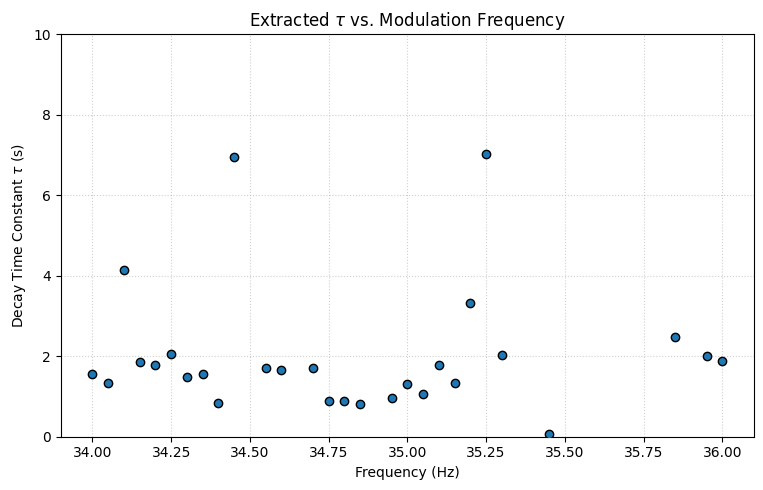

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(frequencies, taus, color='tab:blue', edgecolor='k', zorder=5)
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'Decay Time Constant $\tau$ (s)')
plt.title(r'Extracted $\tau$ vs. Modulation Frequency')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.ylim(0,10)
plt.show()